In [ ]:
# ============================================================
# CELL 1 — Install dependencies & import everything up front
# Run this once at the start. Never need to re-run.
# ============================================================

!pip install deep-translator tqdm wordcloud -q

import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from deep_translator import GoogleTranslator
from tqdm.notebook import tqdm

# Download VADER once here — never again in later cells
nltk.download('vader_lexicon', quiet=True)

print("✅ All libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.2 MB/s eta 0:00:00
✅ All libraries loaded successfully.


In [ ]:
# ============================================================
# CELL 2 — Load the dataset (only once)
# ============================================================

df = pd.read_csv('/content/Daraz_Master_Reviews_bd.csv')

# Quick sanity check — always good to confirm what loaded
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst review sample:\n{df['review_text'].iloc[0]}")

✅ Dataset loaded: 8635 rows, 4 columns

Column names: ['review_text', 'rating', 'date', 'review_length']

First review sample:
প্যাকেজিক ঠিক করতে হবে।দারাজকে ডেলিভারিতে ফোকাস করতে হবে। ডেলিভারি ম্যান বেয়াদব  


In [24]:
# ============================================================
# CELL 3 — Smart translation (Bangla → English only if needed)
# Skips English rows to save time. Shows live progress bar.
# ============================================================

def is_bangla(text):
    """Returns True if text contains Bangla Unicode script characters."""
    return any('\u0980' <= char <= '\u09FF' for char in str(text))

def translate_if_needed(text):
    """Only translates if Bangla script is detected. Skips English rows."""
    text_str = str(text).strip()
    if not is_bangla(text_str):
        return text_str  # Already English or Banglish — skip translation
    try:
        # Truncate to 500 chars — Google Translate free tier limit
        return GoogleTranslator(source='bn', target='en').translate(text_str[:500])
    except Exception:
        return text_str  # If translation fails, keep original

# tqdm wraps .apply() and shows a live progress bar in Colab
tqdm.pandas(desc="Translating reviews")
df['Translated_Text'] = df['review_text'].progress_apply(translate_if_needed)

print(f"\n✅ Translation done.")
bangla_count = df['review_text'].apply(is_bangla).sum()
print(f"   Bangla rows translated: {bangla_count}")
print(f"   English/Banglish rows skipped: {len(df) - bangla_count}")

Translating reviews:   0%|          | 0/8635 [00:00<?, ?it/s]


✅ Translation done.
   Bangla rows translated: 4583
   English/Banglish rows skipped: 4052


In [25]:
# ============================================================
# CELL 4 — Sentiment scoring (VADER + expanded Banglish rules)
# One single function, one single pass. No duplicates.
# ============================================================

sia = SentimentIntensityAnalyzer()

# Expanded from 9 → 20+ words. Also added negatives for accuracy.
POSITIVE_BANGLISH = [
    'darun', 'valoi', 'bhalo', 'thik', 'sundor', 'nice', 'khushi',
    'fast', 'droto', 'onek valo', 'best', 'perfect', 'satisfied',
    'awesome', 'superb', 'dhamakar', 'joriye', 'khub valo', 'aste'
]
NEGATIVE_BANGLISH = [
    'baje', 'kharap', 'nosto', 'fake', 'problem', 'dukho',
    'bekar', 'nirash', 'miss', 'bhul', 'nai', 'pailam na'
]

def get_final_sentiment(row):
    """
    Single-pass sentiment: checks Banglish rules first,
    then falls back to VADER on the translated text.
    """
    original = str(row['review_text']).lower()
    translated = str(row['Translated_Text']).lower()

    # Rule 1: Negative Banglish overrides everything
    if any(word in original for word in NEGATIVE_BANGLISH):
        return 'Negative'

    # Rule 2: Positive Banglish with no negative terms → Positive
    if any(word in original for word in POSITIVE_BANGLISH):
        return 'Positive'

    # Rule 3: Fall back to VADER score on translated text
    score = sia.polarity_scores(translated)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

tqdm.pandas(desc="Scoring sentiment")
df['Final_Sentiment'] = df.progress_apply(get_final_sentiment, axis=1)

print("✅ Sentiment scoring complete.\n")
print(df['Final_Sentiment'].value_counts())

Scoring sentiment:   0%|          | 0/8635 [00:00<?, ?it/s]

✅ Sentiment scoring complete.

Final_Sentiment
Positive    5635
Neutral     1539
Negative    1461
Name: count, dtype: int64


In [26]:
# ============================================================
# CELL 5 — Root cause classification for negative reviews
# Clean, separated logic. Easy to add new categories.
# ============================================================

def classify_issue(row):
    """Labels the main complaint category for negative reviews only."""
    if row['Final_Sentiment'] != 'Negative':
        return 'N/A'

    text = str(row['Translated_Text']).lower()

    if any(w in text for w in ['pack', 'box', 'damage', 'leak', 'broken', 'polythene', 'torn']):
        return 'Packaging & Logistics Damage'
    elif any(w in text for w in ['charge', 'taka', 'extra', 'fee', 'discount', 'price', 'cost']):
        return 'Delivery Fees & Hidden Charges'
    elif any(w in text for w in ['wrong', 'different', 'flavor', 'combo', 'missing', 'vinno', 'mil nai']):
        return 'Incorrect or Mismatched Item'
    elif any(w in text for w in ['quantity', 'weight', 'less', 'small', 'size', 'litter', 'kom']):
        return 'Price & Quantity Dissatisfaction'
    elif any(w in text for w in ['late', 'delay', 'deliver', 'slow', 'deri']):
        return 'Late Delivery'
    else:
        return 'General Product Dissatisfaction'

tqdm.pandas(desc="Classifying issues")
df['Issue_Category'] = df.progress_apply(classify_issue, axis=1)

print("✅ Root cause classification done.\n")
# Only show breakdown for negative reviews
neg_df = df[df['Final_Sentiment'] == 'Negative']
print(f"Negative review issue breakdown ({len(neg_df)} reviews):")
print(neg_df['Issue_Category'].value_counts())

Classifying issues:   0%|          | 0/8635 [00:00<?, ?it/s]

✅ Root cause classification done.

Negative review issue breakdown (1461 reviews):
Issue_Category
General Product Dissatisfaction     811
Packaging & Logistics Damage        181
Delivery Fees & Hidden Charges      172
Price & Quantity Dissatisfaction    150
Incorrect or Mismatched Item         81
Late Delivery                        66
Name: count, dtype: int64


✅ sentiment_chart.html saved.


✅ issue_breakdown.html saved.


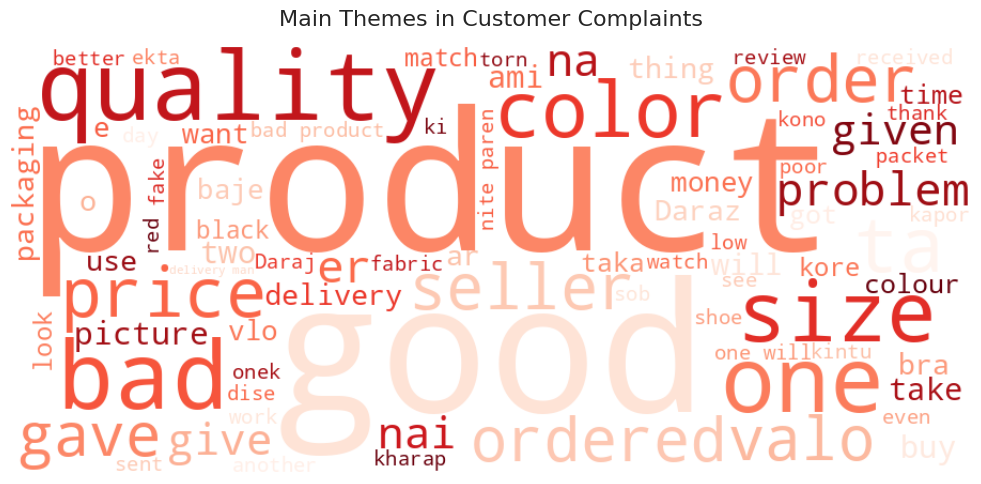

✅ wordcloud.png saved.


In [27]:
# ============================================================
# CELL 6 — Visualizations
# ============================================================

import plotly.express as px

# --- Chart 1: Sentiment Distribution (interactive) ---
sentiment_counts = df['Final_Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

fig = px.bar(
    sentiment_counts,
    x='Sentiment', y='Count',
    color='Sentiment',
    color_discrete_map={
        'Positive': '#2ecc71',
        'Negative': '#e74c3c',
        'Neutral':  '#95a5a6'
    },
    title='Daraz Customer Sentiment Distribution',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, plot_bgcolor='white')
fig.show()
# Save as HTML — paste this into your GitHub README
fig.write_html('sentiment_chart.html')
print("✅ sentiment_chart.html saved.")

# --- Chart 2: Issue Category Breakdown (negative reviews only) ---
issue_counts = df[df['Final_Sentiment'] == 'Negative']['Issue_Category'].value_counts().reset_index()
issue_counts.columns = ['Issue', 'Count']

fig2 = px.bar(
    issue_counts,
    x='Count', y='Issue',
    orientation='h',
    color='Count',
    color_continuous_scale='Reds',
    title='Root Causes of Negative Reviews'
)
fig2.update_layout(yaxis={'categoryorder': 'total ascending'})
fig2.show()
fig2.write_html('issue_breakdown.html')
print("✅ issue_breakdown.html saved.")

# --- Chart 3: Word Cloud (complaints only) ---
negative_text = " ".join(
    df[df['Final_Sentiment'] == 'Negative']['Translated_Text'].astype(str)
)
wordcloud = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='Reds',
    max_words=80
).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Main Themes in Customer Complaints', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ wordcloud.png saved.")

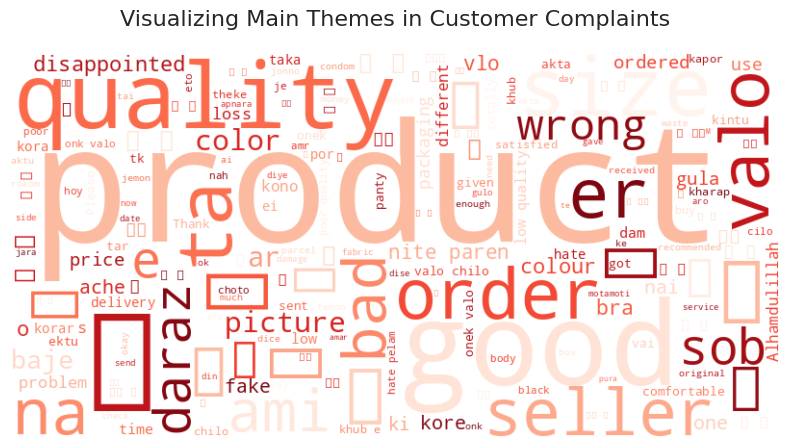

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Grab all text from the negative reviews
negative_text = " ".join(review for review in df[df['Refined_Sentiment']=='Negative'].review_text.astype(str))

# Generate the cloud (ignoring basic English words like 'the', 'is', 'a')
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# Display it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Visualizing Main Themes in Customer Complaints', fontsize=16, pad=20)
plt.show()

In [28]:
# ============================================================
# CELL 7 — Export final dataset (one clean file)
# ============================================================

# Select only meaningful columns for the final export
final_df = df[[
    'review_text',
    'Translated_Text',
    'Final_Sentiment',
    'Issue_Category'
]].copy()

output_path = 'Daraz_Sentiment_Final.csv'
final_df.to_csv(output_path, index=False, encoding='utf-8-sig')  # utf-8-sig opens cleanly in Excel

print(f"✅ Final file saved: {output_path}")
print(f"   Total rows: {len(final_df)}")
print(f"\nPreview:")
print(final_df.head(3))

# Quick summary stats for your README / report
print("\n=== PROJECT SUMMARY ===")
print(final_df['Final_Sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("\nNegative review breakdown:")
print(final_df[final_df['Final_Sentiment']=='Negative']['Issue_Category'].value_counts())

✅ Final file saved: Daraz_Sentiment_Final.csv
   Total rows: 8635

Preview:
                                         review_text  \
0  প্যাকেজিক ঠিক করতে হবে।দারাজকে ডেলিভারিতে ফোকা...   
1  অনেক সুন্দর একটি প্রোডাক্ট খুব সীমিত দামে তাইল...   
2       প্যাকেটের রংটা আলাদা হলেও জিনিস ঠিকঠাক ছিল।    

                                     Translated_Text Final_Sentiment  \
0  The package needs to be fixed. Daraj needs to ...        Negative   
1  A very beautiful product at a very limited pri...        Positive   
2  The color of the packet was different but the ...        Positive   

                 Issue_Category  
0  Packaging & Logistics Damage  
1                           N/A  
2                           N/A  

=== PROJECT SUMMARY ===
Final_Sentiment
Positive    65.3%
Neutral     17.8%
Negative    16.9%
Name: proportion, dtype: object

Negative review breakdown:
Issue_Category
General Product Dissatisfaction     811
Packaging & Logistics Damage        181
Delivery Fees & Hidden C